In [2]:
import os
os.environ["SCIPY_ARRAY_API"] = "1"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from collections import Counter

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, roc_auc_score, accuracy_score,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import xgboost as xgb
import lightgbm as lgb
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

FREQ_COLS = ["500Hz", "1kHz", "2kHz", "3kHz", "4kHz", "6kHz", "8kHz"]
HF_COLS   = ["4kHz", "6kHz", "8kHz"]
LF_COLS   = ["500Hz", "1kHz", "2kHz"]

CLASS_ORDER = ["Normal", "Mild", "Moderate", "Moderate_Severe", "Severe", "Profound"]

print("All libraries loaded successfully.")
print(f"Random state fixed at: {RANDOM_STATE}")

All libraries loaded successfully.
Random state fixed at: 42


In [6]:
# Load audiogram images and extract threshold data
# This cell reads each audiogram PNG from your folder structure and
# extracts the dB threshold at each frequency by reading pixel intensities

import cv2

DATA_ROOT = Path(r"C:\Users\user\Desktop\Audiology")   

FREQ_X_RATIOS = {
    "500Hz": 0.112,
    "1kHz":  0.252,
    "2kHz":  0.392,
    "3kHz":  0.532,
    "4kHz":  0.672,
    "6kHz":  0.812,
    "8kHz":  0.952,
}

# Audiogram y-axis: -10 dB at top, 110 dB at bottom
DB_MIN  = -10
DB_MAX  = 110
PLOT_Y_TOP    = 0.08   # fractional pixel row where -10 dB sits
PLOT_Y_BOTTOM = 0.92   # fractional pixel row where 110 dB sits


def pixel_to_db(pixel_y, img_h):
    """Convert a pixel row to a dB value using linear interpolation."""
    y_top    = PLOT_Y_TOP    * img_h
    y_bottom = PLOT_Y_BOTTOM * img_h
    fraction = (pixel_y - y_top) / (y_bottom - y_top)
    return DB_MIN + fraction * (DB_MAX - DB_MIN)


def extract_thresholds_from_image(img_path):
    """
    Locate the blue plot line at each frequency column and read the dB value.
    Returns a dict {freq: dB} or None if extraction fails.
    """
    img = cv2.imread(str(img_path))
    if img is None:
        return None

    img_h, img_w = img.shape[:2]
    thresholds = {}

    for freq, x_ratio in FREQ_X_RATIOS.items():
        col = int(x_ratio * img_w)
        col = min(max(col, 0), img_w - 1)

        # Search a ±12 px window around the nominal column
        best_row = None
        for c in range(max(0, col - 12), min(img_w, col + 13)):
            for r in range(int(PLOT_Y_TOP * img_h), int(PLOT_Y_BOTTOM * img_h)):
                b, g, red = img[r, c, 0], img[r, c, 1], img[r, c, 2]
                # Blue-dominant pixel (the Matplotlib default line colour)
                if b > 100 and b > g * 1.3 and b > red * 1.3:
                    if best_row is None or r < best_row:
                        best_row = r
        if best_row is not None:
            thresholds[freq] = round(pixel_to_db(best_row, img_h), 1)
        else:
            thresholds[freq] = np.nan

    return thresholds


records = []

folder_name_map = {
    "Mild":             "Mild",
    "Moderate":         "Moderate",
    "Moderately Severe":  "Moderate_Severe",
    "Normal":           "Normal",
    "Profound":         "Profound",
    "Severe":           "Severe",
}

for folder, label in folder_name_map.items():
    folder_path = DATA_ROOT / folder
    if not folder_path.exists():
        print(f"WARNING: folder not found -> {folder_path}")
        continue
    images = list(folder_path.glob("*.png")) + list(folder_path.glob("*.jpg"))
    print(f"  {label}: {len(images)} images found")
    for img_path in images:
        thresh = extract_thresholds_from_image(img_path)
        if thresh:
            thresh["label"] = label
            thresh["file"]  = img_path.name
            records.append(thresh)

raw_df = pd.DataFrame(records)
print(f"\nTotal records extracted: {len(raw_df)}")
print(raw_df.head())

  Mild: 200 images found
  Moderate: 193 images found
  Moderate_Severe: 169 images found
  Normal: 200 images found
  Profound: 84 images found
  Severe: 146 images found

Total records extracted: 992
   500Hz  1kHz  2kHz  3kHz  4kHz  6kHz  8kHz label                file
0    NaN  23.1  13.3  13.3  28.6  37.9   NaN  Mild     audiogram_0.png
1    NaN   9.8  13.1  45.5  65.2  59.5   NaN  Mild   audiogram_100.png
2    NaN  21.4  22.1  13.3  34.3  28.8   NaN  Mild  audiogram_1023.png
3    NaN  14.8   8.8  36.2  49.0  37.9   NaN  Mild    audiogram_11.png
4    NaN  19.3  37.6  56.9  34.8  22.4   NaN  Mild   audiogram_111.png


In [7]:
# Drop rows where more than 2 frequencies could not be extracted
missing_thresh = 2
raw_df["missing_count"] = raw_df[FREQ_COLS].isnull().sum(axis=1)
df = raw_df[raw_df["missing_count"] <= missing_thresh].copy()

print(f"Rows kept after missing filter: {len(df)} / {len(raw_df)}")

# Diagnostic: show how many NaNs exist per frequency per class before imputation
print("\nNaN counts per frequency per class (before imputation):")
nan_report = df.groupby("label")[FREQ_COLS].apply(lambda g: g.isnull().sum())
print(nan_report.to_string())

# Robust imputation strategy:
# Step 1 — fill with class-wise median where the class median is available
for freq in FREQ_COLS:
    class_medians = df.groupby("label")[freq].median()
    for cls, median_val in class_medians.items():
        if not np.isnan(median_val):
            mask = (df["label"] == cls) & (df[freq].isnull())
            df.loc[mask, freq] = median_val

# Step 2 — if an entire class had NaN for a frequency (median was also NaN),
# fall back to the global median across all classes for that frequency
for freq in FREQ_COLS:
    if df[freq].isnull().any():
        global_median = df[freq].median()
        if np.isnan(global_median):
            # Absolute fallback: 25 dB is the clinical boundary for mild loss
            global_median = 25.0
        df[freq] = df[freq].fillna(global_median)
        print(f"  Global fallback applied for {freq}: filled with {global_median:.1f} dB")

# Clip thresholds to valid audiometric range
for freq in FREQ_COLS:
    df[freq] = df[freq].clip(DB_MIN, DB_MAX)

# Confirm class distribution
print("\nClass distribution after cleaning:")
dist = df["label"].value_counts().reindex(CLASS_ORDER)
for cls, count in dist.items():
    print(f"  {cls:20s}: {count}")

# Sanity checks
assert df[FREQ_COLS].isnull().sum().sum() == 0, "NaNs remain after imputation"
assert (df[FREQ_COLS] >= DB_MIN).all().all(), "Values below DB_MIN"
assert (df[FREQ_COLS] <= DB_MAX).all().all(), "Values above DB_MAX"
print("\nAll sanity checks passed.")

Rows kept after missing filter: 991 / 992

NaN counts per frequency per class (before imputation):
                 500Hz  1kHz  2kHz  3kHz  4kHz  6kHz  8kHz
label                                                     
Mild               200     0     0     0     0     0   200
Moderate           193     0     0     0     0     0   193
Moderate_Severe    169     0     0     0     0     0   169
Normal             199     0     0     0     0     0   199
Profound            84     0     0     0     0     0    84
Severe             146     0     0     0     0     0   146
  Global fallback applied for 500Hz: filled with 25.0 dB
  Global fallback applied for 8kHz: filled with 25.0 dB

Class distribution after cleaning:
  Normal              : 199
  Mild                : 200
  Moderate            : 193
  Moderate_Severe     : 169
  Severe              : 146
  Profound            : 84

All sanity checks passed.


In [8]:
# Feature Engineering
def engineer_features(df):
    """
    Build clinically motivated features on top of raw thresholds.
    All operations are applied to the DataFrame passed in, so the
    same function can be called on train and test slices identically.
    """
    d = df.copy()

    # Raw thresholds (already in FREQ_COLS)

    # High-frequency (HF) summary statistics
    d["hf_mean"]  = d[HF_COLS].mean(axis=1)
    d["hf_max"]   = d[HF_COLS].max(axis=1)
    d["hf_slope"] = d["8kHz"] - d["4kHz"]   # positive = worsening towards 8 kHz

    # Low-frequency (LF) pure-tone average
    d["lf_pta"]   = d[LF_COLS].mean(axis=1)

    # Speech-frequency pure-tone average (0.5, 1, 2 kHz — clinical standard)
    d["speech_pta"] = d[["500Hz", "1kHz", "2kHz"]].mean(axis=1)

    # HF notch: how much worse HF is compared to LF
    d["hf_lf_diff"] = d["hf_mean"] - d["lf_pta"]

    # Overall PTA (all 7 frequencies)
    d["overall_pta"] = d[FREQ_COLS].mean(axis=1)

    # Frequency gradient features (adjacent-band differences)
    d["slope_500_1k"] = d["1kHz"]  - d["500Hz"]
    d["slope_1k_2k"]  = d["2kHz"]  - d["1kHz"]
    d["slope_2k_4k"]  = d["4kHz"]  - d["2kHz"]
    d["slope_4k_6k"]  = d["6kHz"]  - d["4kHz"]
    d["slope_6k_8k"]  = d["8kHz"]  - d["6kHz"]

    # HF variance (spread across 4, 6, 8 kHz — flat vs irregular loss)
    d["hf_std"] = d[HF_COLS].std(axis=1)

    # Asymmetry proxy using 4 kHz as the inflection point
    d["low_high_ratio"] = d["lf_pta"] / (d["hf_mean"] + 1e-6)

    return d


df = engineer_features(df)

FEATURE_COLS = (
    FREQ_COLS
    + [
        "hf_mean", "hf_max", "hf_slope",
        "lf_pta", "speech_pta",
        "hf_lf_diff", "overall_pta",
        "slope_500_1k", "slope_1k_2k", "slope_2k_4k",
        "slope_4k_6k", "slope_6k_8k",
        "hf_std", "low_high_ratio",
    ]
)

print(f"Total features: {len(FEATURE_COLS)}")
print("Feature list:")
for f in FEATURE_COLS:
    print(f"  {f}")

Total features: 21
Feature list:
  500Hz
  1kHz
  2kHz
  3kHz
  4kHz
  6kHz
  8kHz
  hf_mean
  hf_max
  hf_slope
  lf_pta
  speech_pta
  hf_lf_diff
  overall_pta
  slope_500_1k
  slope_1k_2k
  slope_2k_4k
  slope_4k_6k
  slope_6k_8k
  hf_std
  low_high_ratio


In [9]:
# Encode labels and define train/test split
le = LabelEncoder()
le.fit(CLASS_ORDER)

X = df[FEATURE_COLS].values
y = le.transform(df["label"].values)

print("Class encoding:")
for idx, cls in enumerate(le.classes_):
    print(f"  {idx} -> {cls}")

# Stratified 80/20 hold-out split  
# We do this ONCE here and never touch the test set again until final evaluation
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"\nTraining samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

print("\nTraining class distribution:")
train_dist = Counter(y_train)
for cls_idx, count in sorted(train_dist.items()):
    print(f"  {le.classes_[cls_idx]:20s}: {count}")

print("\nTest class distribution:")
test_dist = Counter(y_test)
for cls_idx, count in sorted(test_dist.items()):
    print(f"  {le.classes_[cls_idx]:20s}: {count}")

Class encoding:
  0 -> Mild
  1 -> Moderate
  2 -> Moderate_Severe
  3 -> Normal
  4 -> Profound
  5 -> Severe

Training samples : 792
Test samples     : 199

Training class distribution:
  Mild                : 160
  Moderate            : 154
  Moderate_Severe     : 135
  Normal              : 159
  Profound            : 67
  Severe              : 117

Test class distribution:
  Mild                : 40
  Moderate            : 39
  Moderate_Severe     : 34
  Normal              : 40
  Profound            : 17
  Severe              : 29


In [10]:
# SMOTE is applied INSIDE each CV fold to prevent leakage.
# The ImbPipeline ensures synthetic samples are never generated
# from validation data.

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def make_pipeline(classifier):
    """Wrap any classifier in a SMOTE + StandardScaler pipeline."""
    return ImbPipeline([
        ("smote",  SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
        ("scaler", StandardScaler()),
        ("clf",    classifier),
    ])


classifiers = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, C=1.0,
        multi_class="multinomial",
        solver="lbfgs",
        random_state=RANDOM_STATE
    ),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "SVM": SVC(
        kernel="rbf", C=10, gamma="scale",
        probability=True,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05,
        max_depth=4,
        random_state=RANDOM_STATE
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05,
        max_depth=5, use_label_encoder=False,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        verbose=-1
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation="relu",
        max_iter=500,
        early_stopping=True,
        random_state=RANDOM_STATE
    ),
}

cv_results = {}

print("Running 5-fold stratified cross-validation (SMOTE inside each fold)...")
print("-" * 65)

for name, clf in classifiers.items():
    pipe = make_pipeline(clf)
    # cross_val_predict produces out-of-fold predictions with no leakage
    oof_preds = cross_val_predict(
        pipe, X_train, y_train,
        cv=CV, method="predict", n_jobs=-1
    )
    acc  = accuracy_score(y_train, oof_preds)
    mf1  = f1_score(y_train, oof_preds, average="macro")
    wf1  = f1_score(y_train, oof_preds, average="weighted")

    cv_results[name] = {
        "OOF Accuracy":   round(acc  * 100, 2),
        "Macro F1":       round(mf1  * 100, 2),
        "Weighted F1":    round(wf1  * 100, 2),
    }
    print(f"  {name:25s} | Acc: {acc*100:.2f}% | Macro-F1: {mf1*100:.2f}% | Weighted-F1: {wf1*100:.2f}%")

print("-" * 65)

cv_df = pd.DataFrame(cv_results).T.sort_values("Macro F1", ascending=False)
print("\nRanked by Macro F1 (cross-validation):")
print(cv_df.to_string())

Running 5-fold stratified cross-validation (SMOTE inside each fold)...
-----------------------------------------------------------------
  Logistic Regression       | Acc: 96.21% | Macro-F1: 96.52% | Weighted-F1: 96.21%
  KNN                       | Acc: 90.53% | Macro-F1: 91.18% | Weighted-F1: 90.54%
  SVM                       | Acc: 94.95% | Macro-F1: 95.37% | Weighted-F1: 94.95%
  Random Forest             | Acc: 95.83% | Macro-F1: 95.74% | Weighted-F1: 95.84%
  Gradient Boosting         | Acc: 96.34% | Macro-F1: 96.63% | Weighted-F1: 96.34%
  XGBoost                   | Acc: 96.97% | Macro-F1: 97.03% | Weighted-F1: 96.97%
  LightGBM                  | Acc: 96.72% | Macro-F1: 96.91% | Weighted-F1: 96.72%
  MLP                       | Acc: 93.31% | Macro-F1: 93.41% | Weighted-F1: 93.30%
-----------------------------------------------------------------

Ranked by Macro F1 (cross-validation):
                     OOF Accuracy  Macro F1  Weighted F1
XGBoost                     96.97   

In [11]:
best_model_name = cv_df.index[0]
print(f"Best model (by Macro F1): {best_model_name}")
best_clf_raw = classifiers[best_model_name]
best_pipeline = make_pipeline(best_clf_raw)
# Fit on the full training set (SMOTE applied to the whole training set here)
best_pipeline.fit(X_train, y_train)
print("Final model trained on full training set.")

Best model (by Macro F1): XGBoost
Final model trained on full training set.


In [12]:
#  evaluation on held-out test set
y_pred  = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)

test_acc  = accuracy_score(y_test, y_pred)
test_mf1  = f1_score(y_test, y_pred, average="macro")
test_wf1  = f1_score(y_test, y_pred, average="weighted")

try:
    test_auc = roc_auc_score(
        y_test, y_proba,
        multi_class="ovr", average="macro"
    )
except Exception:
    test_auc = float("nan")

print("FINAL TEST SET RESULTS")
print("-" * 45)
print(f"  Model         : {best_model_name}")
print(f"  Accuracy      : {test_acc * 100:.2f}%")
print(f"  Macro F1      : {test_mf1 * 100:.2f}%")
print(f"  Weighted F1   : {test_wf1 * 100:.2f}%")
print(f"  ROC-AUC (OvR) : {test_auc:.4f}")
print("-" * 45)
print("\nPer-class classification report:")
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_
))

FINAL TEST SET RESULTS
---------------------------------------------
  Model         : XGBoost
  Accuracy      : 94.97%
  Macro F1      : 95.39%
  Weighted F1   : 94.93%
  ROC-AUC (OvR) : 0.9987
---------------------------------------------

Per-class classification report:
                 precision    recall  f1-score   support

           Mild       1.00      0.85      0.92        40
       Moderate       0.95      1.00      0.97        39
Moderate_Severe       0.92      0.97      0.94        34
         Normal       0.89      1.00      0.94        40
       Profound       1.00      1.00      1.00        17
         Severe       1.00      0.90      0.95        29

       accuracy                           0.95       199
      macro avg       0.96      0.95      0.95       199
   weighted avg       0.95      0.95      0.95       199



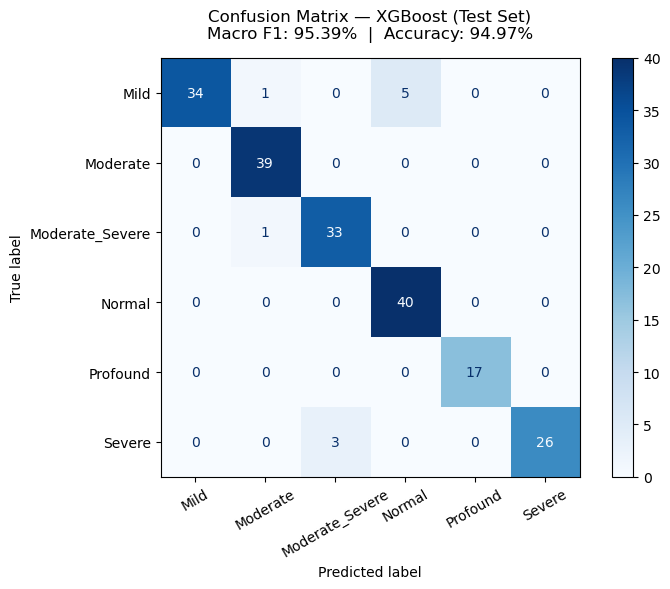

In [13]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)
disp.plot(ax=ax, colorbar=True, cmap="Blues", xticks_rotation=30)
ax.set_title(
    f"Confusion Matrix — {best_model_name} (Test Set)\n"
    f"Macro F1: {test_mf1*100:.2f}%  |  Accuracy: {test_acc*100:.2f}%",
    fontsize=12, pad=14
)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

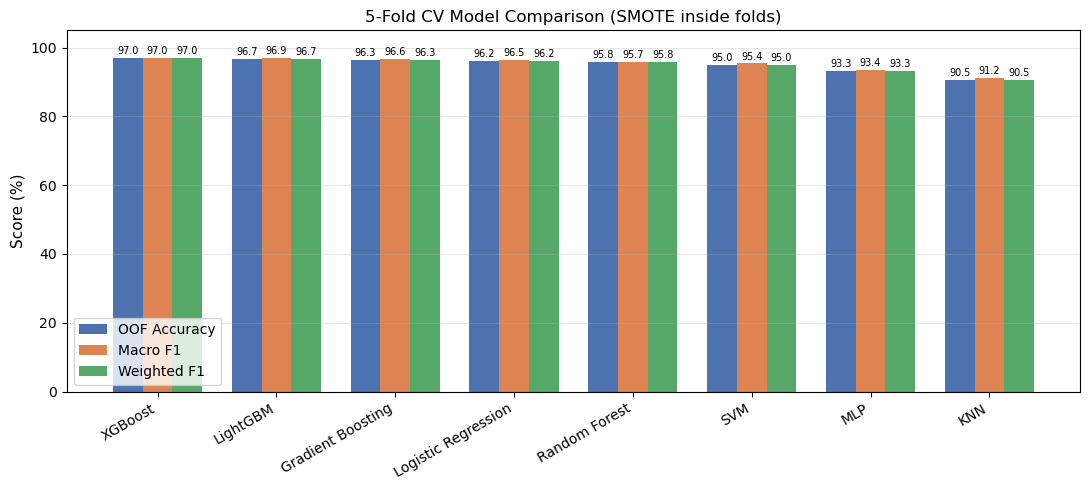

In [14]:
# Cross validation comparism bar chart
metrics_to_plot = ["OOF Accuracy", "Macro F1", "Weighted F1"]
plot_df = cv_df[metrics_to_plot].copy()

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(plot_df))
width = 0.25

bars0 = ax.bar(x - width, plot_df["OOF Accuracy"], width, label="OOF Accuracy",  color="#4C72B0")
bars1 = ax.bar(x,          plot_df["Macro F1"],     width, label="Macro F1",      color="#DD8452")
bars2 = ax.bar(x + width,  plot_df["Weighted F1"],  width, label="Weighted F1",   color="#55A868")

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=30, ha="right", fontsize=10)
ax.set_ylabel("Score (%)", fontsize=11)
ax.set_title("5-Fold CV Model Comparison (SMOTE inside folds)", fontsize=12)
ax.set_ylim(0, 105)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

for bars in [bars0, bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.5, f"{h:.1f}",
            ha="center", va="bottom", fontsize=7
        )

plt.tight_layout()
plt.savefig("cv_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# Extract scaler and classifier from the best pipeline
scaler_step = best_pipeline.named_steps["scaler"]
clf_step    = best_pipeline.named_steps["clf"]

X_train_scaled = scaler_step.transform(X_train)
X_test_scaled  = scaler_step.transform(X_test)

model_type = type(clf_step).__name__
print(f"Best model type: {model_type}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

# Build explainer
if model_type in ("XGBClassifier", "LGBMClassifier",
                  "RandomForestClassifier", "GradientBoostingClassifier"):
    explainer  = shap.TreeExplainer(clf_step)
    shap_raw   = explainer.shap_values(X_test_scaled)
else:
    background = shap.kmeans(X_train_scaled, 50)
    explainer  = shap.KernelExplainer(clf_step.predict_proba, background)
    shap_raw   = explainer.shap_values(X_test_scaled[:100])

print(f"shap_raw type  : {type(shap_raw)}")
if isinstance(shap_raw, np.ndarray):
    print(f"shap_raw shape : {shap_raw.shape}")
elif isinstance(shap_raw, list):
    print(f"shap_raw length: {len(shap_raw)}")
    print(f"shap_raw[0] shape: {np.array(shap_raw[0]).shape}")

# Normalise to a consistent format: list of 2D arrays, one per class
# SHAP can return either:
#   (a) list of (n_samples, n_features) arrays   — older SHAP / some models
#   (b) 3D array of shape (n_samples, n_features, n_classes) — newer SHAP
#   (c) single 2D array (n_samples, n_features)  — binary or single output

if isinstance(shap_raw, np.ndarray):
    if shap_raw.ndim == 3:
        # Shape: (n_samples, n_features, n_classes) — transpose to list
        shap_values = [shap_raw[:, :, i] for i in range(shap_raw.shape[2])]
        print(f"Converted 3D array -> list of {len(shap_values)} class arrays")
    elif shap_raw.ndim == 2:
        # Single output (binary) — wrap in list
        shap_values = [shap_raw]
        print("Single 2D array wrapped into list")
    else:
        raise ValueError(f"Unexpected shap_raw ndim: {shap_raw.ndim}")

elif isinstance(shap_raw, list):
    # Already a list — ensure each element is a 2D numpy array
    shap_values = [np.array(sv) for sv in shap_raw]
    # Some versions return (n_classes, n_samples, n_features) as a list
    # Detect and fix if individual arrays are 1D or wrong shape
    if shap_values[0].ndim == 1:
        # Likely (n_classes,) list of (n_samples * n_features) — reshape
        n_samples = X_test_scaled.shape[0]
        shap_values = [sv.reshape(n_samples, -1) for sv in shap_values]
        print("Reshaped 1D list elements to 2D")
    print(f"List of {len(shap_values)} arrays, each shape: {shap_values[0].shape}")

else:
    raise ValueError(f"Unrecognised shap_raw type: {type(shap_raw)}")

# Compute global feature importance: mean |SHAP| across all classes and samples
# Each shap_values[i] is (n_samples, n_features)
mean_abs_shap = np.mean(
    [np.abs(sv) for sv in shap_values], axis=0   # average over classes -> (n_samples, n_features)
).mean(axis=0)                                    # average over samples  -> (n_features,)

assert mean_abs_shap.shape == (len(FEATURE_COLS),), \
    f"Expected ({len(FEATURE_COLS)},), got {mean_abs_shap.shape}"

global_importance = pd.Series(
    mean_abs_shap,
    index=FEATURE_COLS
).sort_values(ascending=False)

print("\nTop 15 features by mean absolute SHAP value:")
print(global_importance.head(15).round(4).to_string())

Best model type: XGBClassifier
X_test_scaled shape: (199, 21)
shap_raw type  : <class 'numpy.ndarray'>
shap_raw shape : (199, 21, 6)
Converted 3D array -> list of 6 class arrays

Top 15 features by mean absolute SHAP value:
overall_pta       2.6876
1kHz              0.5220
lf_pta            0.2182
hf_max            0.1500
6kHz              0.1466
hf_mean           0.1048
slope_1k_2k       0.0965
2kHz              0.0611
slope_4k_6k       0.0604
slope_2k_4k       0.0512
4kHz              0.0469
3kHz              0.0325
hf_std            0.0227
low_high_ratio    0.0144
hf_lf_diff        0.0076


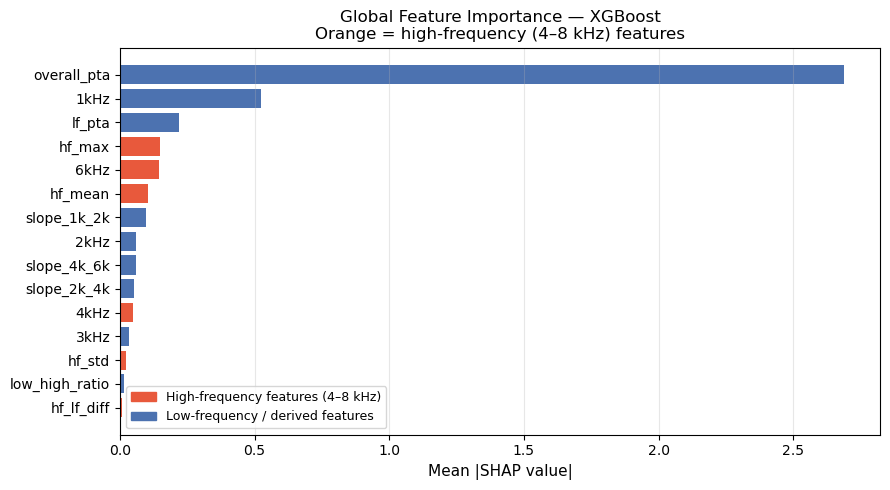

In [17]:
top_features = global_importance.head(15)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#E8593C" if f in HF_COLS or "hf" in f else "#4C72B0"
          for f in top_features.index]

ax.barh(top_features.index[::-1], top_features.values[::-1], color=colors[::-1])
ax.set_xlabel("Mean |SHAP value|", fontsize=11)
ax.set_title(
    f"Global Feature Importance — {best_model_name}\n"
    "Orange = high-frequency (4–8 kHz) features",
    fontsize=12
)
ax.grid(axis="x", alpha=0.3)

hf_patch  = mpatches.Patch(color="#E8593C", label="High-frequency features (4–8 kHz)")
lf_patch  = mpatches.Patch(color="#4C72B0", label="Low-frequency / derived features")
ax.legend(handles=[hf_patch, lf_patch], fontsize=9)

plt.tight_layout()
plt.savefig("shap_global_importance.png", dpi=150, bbox_inches="tight")
plt.show()

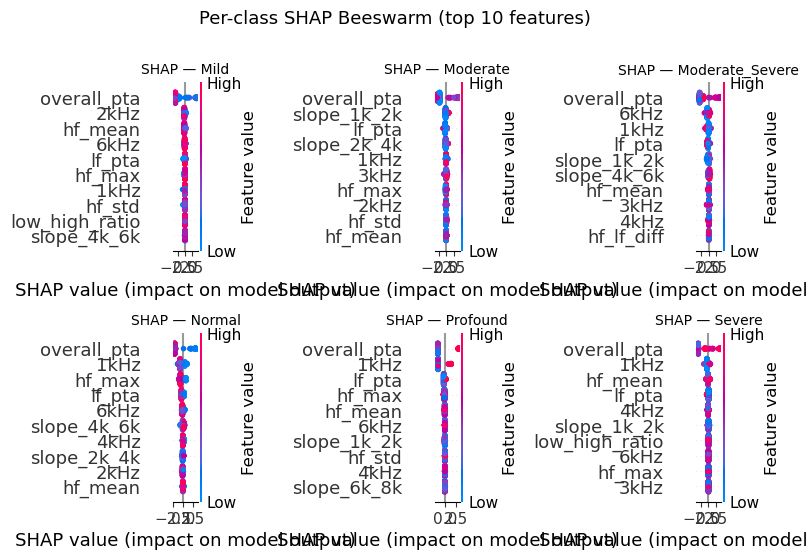

Saved: shap_beeswarm_perclass.png


In [18]:
if isinstance(shap_values, list) and len(shap_values) > 1:
    n_classes = len(shap_values)
    n_cols    = 3
    n_rows    = int(np.ceil(n_classes / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
    axes      = axes.flatten()

    # Use the same X that SHAP was computed on
    X_shap = X_test_scaled if shap_values[0].shape[0] == X_test_scaled.shape[0] \
             else X_test_scaled[:100]

    for i, cls in enumerate(le.classes_):
        plt.sca(axes[i])
        # shap_values[i] is guaranteed 2D (n_samples, n_features) here
        shap.summary_plot(
            shap_values[i],
            X_shap,
            feature_names=FEATURE_COLS,
            max_display=10,
            show=False,
            plot_type="dot"
        )
        axes[i].set_title(f"SHAP — {cls}", fontsize=10)

    # Hide unused subplots if n_classes is not a multiple of n_cols
    for j in range(n_classes, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Per-class SHAP Beeswarm (top 10 features)", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("shap_beeswarm_perclass.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: shap_beeswarm_perclass.png")

else:
    shap.summary_plot(
        shap_values[0],
        X_test_scaled,
        feature_names=FEATURE_COLS,
        max_display=15
    )

In [19]:
# Binary early-detection analysis (Normal+Mild vs rest)
# Research question sub-analysis:
# Can we detect early-stage loss using HF features only?

EARLY_CLASSES = {"Normal", "Mild"}

y_binary_train = np.array(
    [0 if le.classes_[yi] in EARLY_CLASSES else 1 for yi in y_train]
)
y_binary_test = np.array(
    [0 if le.classes_[yi] in EARLY_CLASSES else 1 for yi in y_test]
)

# HF-only feature indices
hf_feature_names = [
    "4kHz", "6kHz", "8kHz",
    "hf_mean", "hf_max", "hf_slope", "hf_lf_diff", "hf_std"
]
hf_indices = [FEATURE_COLS.index(f) for f in hf_feature_names]

X_train_hf = X_train[:, hf_indices]
X_test_hf  = X_test[:, hf_indices]

binary_pipe = ImbPipeline([
    ("smote",  SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
    ("scaler", StandardScaler()),
    ("clf",    xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, use_label_encoder=False,
        eval_metric="logloss",
        random_state=RANDOM_STATE
    )),
])

oof_binary = cross_val_predict(
    binary_pipe, X_train_hf, y_binary_train,
    cv=CV, method="predict"
)
cv_f1_binary = f1_score(y_binary_train, oof_binary, average="macro")
cv_acc_binary = accuracy_score(y_binary_train, oof_binary)

binary_pipe.fit(X_train_hf, y_binary_train)
y_pred_binary = binary_pipe.predict(X_test_hf)

test_f1_binary  = f1_score(y_binary_test, y_pred_binary, average="macro")
test_acc_binary = accuracy_score(y_binary_test, y_pred_binary)
test_auc_binary = roc_auc_score(
    y_binary_test,
    binary_pipe.predict_proba(X_test_hf)[:, 1]
)

print("BINARY EARLY-DETECTION ANALYSIS (HF-only features)")
print("-" * 52)
print(f"  Classes: 0 = Normal/Mild  |  1 = Moderate and above")
print(f"  Features used: {hf_feature_names}")
print()
print(f"  CV Macro F1      : {cv_f1_binary * 100:.2f}%")
print(f"  CV Accuracy      : {cv_acc_binary * 100:.2f}%")
print()
print(f"  Test Macro F1    : {test_f1_binary * 100:.2f}%")
print(f"  Test Accuracy    : {test_acc_binary * 100:.2f}%")
print(f"  Test ROC-AUC     : {test_auc_binary:.4f}")
print("-" * 52)
print("\nClassification report (binary):")
print(classification_report(
    y_binary_test, y_pred_binary,
    target_names=["Normal/Mild (no early loss)", "Moderate+ (established loss)"]
))

BINARY EARLY-DETECTION ANALYSIS (HF-only features)
----------------------------------------------------
  Classes: 0 = Normal/Mild  |  1 = Moderate and above
  Features used: ['4kHz', '6kHz', '8kHz', 'hf_mean', 'hf_max', 'hf_slope', 'hf_lf_diff', 'hf_std']

  CV Macro F1      : 97.24%
  CV Accuracy      : 97.35%

  Test Macro F1    : 95.85%
  Test Accuracy    : 95.98%
  Test ROC-AUC     : 0.9933
----------------------------------------------------

Classification report (binary):
                              precision    recall  f1-score   support

 Normal/Mild (no early loss)       0.93      0.97      0.95        80
Moderate+ (established loss)       0.98      0.95      0.97       119

                    accuracy                           0.96       199
                   macro avg       0.96      0.96      0.96       199
                weighted avg       0.96      0.96      0.96       199



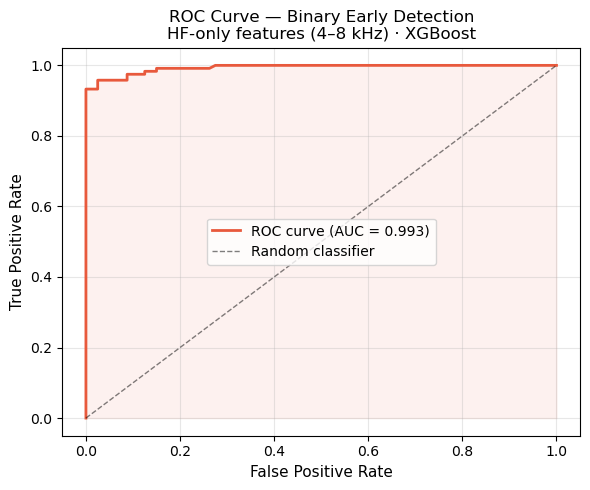

In [20]:
# ROC curve for binary task
from sklearn.metrics import roc_curve

y_scores = binary_pipe.predict_proba(X_test_hf)[:, 1]
fpr, tpr, thresholds = roc_curve(y_binary_test, y_scores)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="#E8593C", lw=2,
        label=f"ROC curve (AUC = {test_auc_binary:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random classifier")
ax.fill_between(fpr, tpr, alpha=0.08, color="#E8593C")

ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title(
    "ROC Curve — Binary Early Detection\n"
    "HF-only features (4–8 kHz) · XGBoost",
    fontsize=12
)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curve_binary.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
summary_data = {
    "Task": [
        "Multi-class (6 classes) — CV",
        "Multi-class (6 classes) — Test",
        "Binary early detection — CV (HF only)",
        "Binary early detection — Test (HF only)",
    ],
    "Model": [
        best_model_name,
        best_model_name,
        "XGBoost (HF features)",
        "XGBoost (HF features)",
    ],
    "Accuracy (%)": [
        cv_df.loc[best_model_name, "OOF Accuracy"],
        round(test_acc * 100, 2),
        round(cv_acc_binary * 100, 2),
        round(test_acc_binary * 100, 2),
    ],
    "Macro F1 (%)": [
        cv_df.loc[best_model_name, "Macro F1"],
        round(test_mf1 * 100, 2),
        round(cv_f1_binary * 100, 2),
        round(test_f1_binary * 100, 2),
    ],
    "ROC-AUC": [
        "N/A",
        round(test_auc, 4) if not np.isnan(test_auc) else "N/A",
        "N/A",
        round(test_auc_binary, 4),
    ],
}

summary_df = pd.DataFrame(summary_data)
print("\nFINAL PROJECT SUMMARY")
print(summary_df.to_string(index=False))

summary_df.to_csv("results_summary.csv", index=False)


FINAL PROJECT SUMMARY
                                   Task                 Model  Accuracy (%)  Macro F1 (%) ROC-AUC
           Multi-class (6 classes) — CV               XGBoost         96.97         97.03     N/A
         Multi-class (6 classes) — Test               XGBoost         94.97         95.39  0.9987
  Binary early detection — CV (HF only) XGBoost (HF features)         97.35         97.24     N/A
Binary early detection — Test (HF only) XGBoost (HF features)         95.98         95.85  0.9933
